# Predicting AI & Data Science Salaries by using Linear Regression 

Using a Kaggle synthetic dataset of 5,000 AI/Data Science roles, I used Linear Regression to predict `salary_usd` using different factors like jobs, companies, and behavioral features. This helped answer what factors are associated with getting paid more than others. 

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
df = pd.read_csv("ai_ds_job_salaries_2026.csv")

In [3]:
df.head()

,job_title,experience_level,employment_type,company_size,company_location,employee_residence,industry,remote_ratio,years_experience,education_level,...,ai_tools_hours_per_week,salary_currency,salary_usd,equity_offered_pct,bonus_pct,job_satisfaction_score,interviews_to_offer,switched_jobs_last_year,upskilling_hours_per_month,fears_ai_automation_score
0,Data Analyst,Lead,Part-time,S,IN,AU,Finance,0,14.4,Bachelors,...,12.5,INR,23844,0.505,11.6,5.5,8,True,2.2,7.4
1,Research Scientist,Senior,Full-time,L,US,US,Retail,50,7.6,Masters,...,2.1,USD,170132,0.054,2.9,7.0,3,False,8.2,5.3
2,Machine Learning Engineer,Entry,Full-time,M,US,US,Government,0,0.0,Bootcamp,...,5.1,USD,83059,0.191,7.5,5.9,1,False,2.8,6.8
3,Data Engineer,Senior,Full-time,M,BR,IN,Government,100,9.7,Masters,...,2.0,BRL,29531,0.102,9.3,5.6,5,False,7.8,5.0
4,Data Engineer,Mid,Full-time,M,US,US,Education,0,3.2,Bachelors,...,4.0,USD,70105,0.064,10.6,4.6,4,False,9.1,5.1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 27 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   job_title                   5000 non-null   object 
 1   experience_level            5000 non-null   object 
 2   employment_type             5000 non-null   object 
 3   company_size                5000 non-null   object 
 4   company_location            5000 non-null   object 
 5   employee_residence          5000 non-null   object 
 6   industry                    5000 non-null   object 
 7   remote_ratio                5000 non-null   int64  
 8   years_experience            5000 non-null   float64
 9   education_level             5000 non-null   object 
 10  primary_language            5000 non-null   object 
 11  has_ml_in_title             5000 non-null   bool   
 12  manages_people              5000 non-null   bool   
 13  team_size                   5000 

In [5]:
df['employment_type'].value_counts()

employment_type
Full-time    4159
Contract      418
Freelance     212
Part-time     211
Name: count, dtype: int64

In [6]:
df['company_location'].value_counts()

company_location
US    1786
IN     782
GB     488
DE     350
CA     350
AU     240
BR     210
NL     200
FR     189
PL     147
SG     130
ES     128
Name: count, dtype: int64

In [7]:
df['remote_ratio'].value_counts()

remote_ratio
0      2112
50     1468
100    1420
Name: count, dtype: int64

## Encoding Categorical Features 
I encoded with `drop_first=True` to stop multicollinearity between the dummy variables. This causes each coefficient to represent the salary difference from the  baseline category, instead of producing unstable values. 

In [8]:
df.describe()

,remote_ratio,years_experience,team_size,certifications_count,weekly_hours,ai_tools_hours_per_week,salary_usd,equity_offered_pct,bonus_pct,job_satisfaction_score,interviews_to_offer,upskilling_hours_per_month,fears_ai_automation_score
count,5000.00000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,43.08000,8.361440,7.93620,1.820400,44.345400,8.437400,98605.406200,0.139020,10.802720,6.685320,5.230800,8.680740,4.846080
std,41.45428,4.820808,2.64793,1.344212,6.142761,5.503637,55369.310473,0.184243,5.152959,1.364302,2.412695,4.422549,1.725924
min,0.00000,0.000000,1.00000,0.000000,24.400000,0.000000,12000.000000,0.000000,0.000000,1.100000,1.000000,0.000000,1.000000
25%,0.00000,4.800000,6.00000,1.000000,40.100000,3.300000,55592.750000,0.017000,7.100000,5.800000,3.000000,5.600000,3.700000
50%,50.00000,8.100000,8.00000,2.000000,44.400000,8.500000,90572.000000,0.072000,10.600000,6.700000,5.000000,8.700000,4.800000
75%,100.00000,11.500000,10.00000,3.000000,48.500000,12.625000,129657.750000,0.175000,14.200000,7.600000,7.000000,11.700000,6.000000
max,100.00000,23.700000,19.00000,8.000000,67.300000,25.200000,372347.000000,1.264000,30.800000,10.000000,16.000000,26.200000,10.000000


In [9]:
df = pd.get_dummies(df, columns=['experience_level','employment_type','company_size','company_location','industry','education_level'], drop_first=True)
print(df.shape)
print(df.columns.tolist())

from sklearn.model_selection import train_test_split

(5000, 54)
['job_title', 'employee_residence', 'remote_ratio', 'years_experience', 'primary_language', 'has_ml_in_title', 'manages_people', 'team_size', 'certifications_count', 'weekly_hours', 'uses_ai_tools_daily', 'ai_tools_hours_per_week', 'salary_currency', 'salary_usd', 'equity_offered_pct', 'bonus_pct', 'job_satisfaction_score', 'interviews_to_offer', 'switched_jobs_last_year', 'upskilling_hours_per_month', 'fears_ai_automation_score', 'experience_level_Executive', 'experience_level_Lead', 'experience_level_Mid', 'experience_level_Senior', 'employment_type_Freelance', 'employment_type_Full-time', 'employment_type_Part-time', 'company_size_M', 'company_size_S', 'company_location_BR', 'company_location_CA', 'company_location_DE', 'company_location_ES', 'company_location_FR', 'company_location_GB', 'company_location_IN', 'company_location_NL', 'company_location_PL', 'company_location_SG', 'company_location_US', 'industry_Education', 'industry_Energy', 'industry_Finance', 'industry_G

In [10]:
X = df.drop(columns=['salary_usd', 'job_title', 'employee_residence','primary_language', 'salary_currency'])
y = df['salary_usd']


In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [34]:
X_train.head()

,remote_ratio,years_experience,has_ml_in_title,manages_people,team_size,certifications_count,weekly_hours,uses_ai_tools_daily,ai_tools_hours_per_week,equity_offered_pct,...,industry_Government,industry_Healthcare,industry_Manufacturing,industry_Media,industry_Retail,industry_Technology,education_level_Bootcamp,education_level_Masters,education_level_PhD,education_level_Self-taught
1840,100,5.8,False,False,10,1,35.6,True,10.3,0.207,...,False,False,False,False,False,True,True,False,False,False
2115,50,10.4,False,False,8,5,42.7,True,8.8,0.628,...,False,True,False,False,False,False,False,True,False,False
4437,50,3.6,True,False,11,2,32.0,True,11.6,0.016,...,False,False,False,False,False,True,False,False,False,True
1146,0,14.0,True,True,11,1,45.6,True,12.1,0.092,...,False,False,False,False,False,True,False,False,False,False
2486,0,12.2,False,False,10,2,40.5,True,4.1,0.268,...,False,True,False,False,False,False,False,True,False,False


In [13]:
from sklearn.linear_model import LinearRegression

In [14]:
lm = LinearRegression()

In [15]:
lm.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [16]:

cdf = pd.DataFrame(lm.coef_, X.columns, columns=['Coef'])

coef_findings = ['has_ml_in_title', 'experience_level_Executive', 'education_level_PhD', 
                      'company_location_US', 'company_location_IN', 'uses_ai_tools_daily']

for f in coef_findings:
    print(f, cdf.loc[f, 'Coef'])

has_ml_in_title 16518.583484716863
experience_level_Executive 77175.01924755529
education_level_PhD 15615.914937006868
company_location_US 30302.97411276399
company_location_IN -65782.63736617353
uses_ai_tools_daily 2127.5045320823374


### Important Findings from Coefficients

- Having "ML" in your title: **+\$16,519**
- Executive vs. Entry-level: **+\$77,175**
- PhD vs. Bachelor's (controlling for experience): **+\$15,616**
- US vs. Australia (company location): **+\$30,303**
- India vs. Australia (company location): **−\$65,783**
- Daily AI-tool use: **+\$2,128** — a modest premium, not a pay cut

In [17]:
lm.coef_

array([ 3.61031742e+01,  1.10305785e+03,  1.65185835e+04,  4.72027155e+02,
        1.66674335e+02, -1.09382309e+02, -2.41564061e+01,  2.12750453e+03,
        1.83332336e+02, -1.80081863e+03,  7.43707445e+01,  8.52508249e+02,
       -1.25869323e+02,  6.50411570e+02,  5.47454891e+01, -1.25373911e+03,
        7.71750192e+04,  5.78594209e+04,  1.70758277e+04,  3.58282419e+04,
       -6.09101942e+03,  5.27143509e+03, -3.82532956e+04, -1.46321402e+04,
       -2.69543355e+04, -6.24942256e+04, -1.55838613e+03, -9.67511037e+03,
       -3.50386775e+04, -2.12460256e+04, -5.73305716e+03, -6.57826374e+04,
       -6.91440871e+03, -4.40487957e+04, -1.14723690e+04,  3.03029741e+04,
       -1.61874086e+04, -7.00821969e+02,  1.41232895e+04, -1.75083176e+04,
       -1.33637189e+03, -6.09607751e+03, -6.42023000e+03, -4.20496612e+03,
        9.40915727e+03, -5.27176093e+03,  6.81724464e+03,  1.56159149e+04,
       -6.52203058e+03])

## Generating Predictions 
With the model trained, the next step is testing it on the 30% unseen data. The `X_test` set contains data the model has never encountered, so we can see how well it generalizes to new data.

In [18]:
predictions = lm.predict(X_test)

In [19]:
predictions

array([ 32917.29932602, 102158.42341056,  28072.62921053, ...,
       105607.10475861, 133446.05372496, 140386.16527739], shape=(1500,))

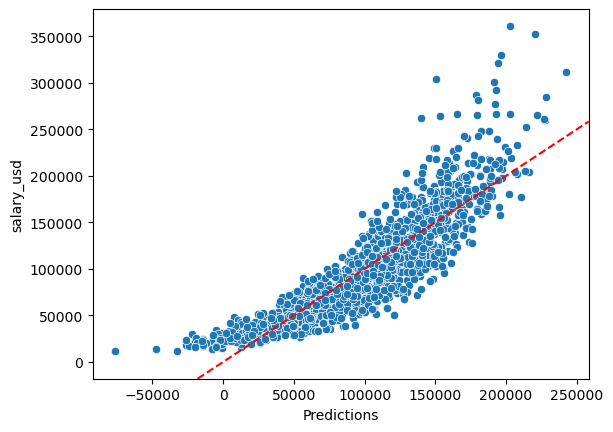

In [20]:
sns.scatterplot(x=predictions, y=y_test)
plt.xlabel("Predictions")
plt.axline((0, 0), slope=1, color='red', linestyle='--') 

## Identifying a Weakness 
On my scatterplot, predictions fan out further from the diagonal line at high salaries, and a few points dip below zero — an impossible value for real salary. This fanning pattern suggests heteroscedasticity: the model's errors get larger and less consistent as predicted salary increases. We look at this issue further via residual analysis below.

In [21]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import math

In [22]:
print("Mean Absolute Error; ", mean_absolute_error(y_test, predictions))
print("Mean Squared Error; ", mean_squared_error(y_test, predictions))
print("RMSE; ", math.sqrt(mean_squared_error(y_test,predictions))) 

Mean Absolute Error;  19587.507039754186
Mean Squared Error;  682994968.6830755
RMSE;  26134.172431570805


In [23]:
print(y_test.mean())
print(y_test.median())
from sklearn.metrics import r2_score
print("R²: ", r2_score(y_test, predictions))

98663.622
90963.0
R²:  0.7787125352835282


In [24]:
residuals = y_test - predictions
residuals

1501     4058.700674
2586   -36421.423411
2653     3482.370789
1055   -13164.461377
705    -10020.884462
            ...     
3563   -10655.286155
1538     5649.676280
1837   -11791.104759
2380   -37283.053725
1912    62910.834723
Name: salary_usd, Length: 1500, dtype: float64

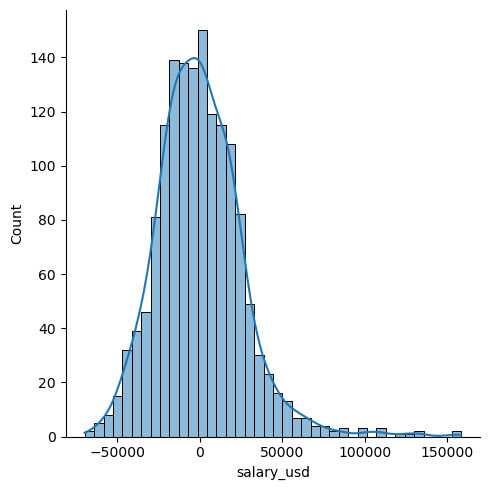

In [25]:
sns.displot(residuals, bins=40, kde=True)

## Residual Analysis
Right-skewed distribution of residuals (mean = 203 USD, median = -1,378 USD). This supports what the scatterplot suggested: the model is fairly balanced overall, but has a long tail of large positive residuals (up to 158,477 USD), showing that the model underpredicts the salaries of some of the highest earners. The asymmetry between the maximum (+158K USD) and minimum (-70K USD) residuals, along with the increasing spread of residuals in the scatterplot, suggests heteroscedasticity. This leads us to test a log transformation next.

In [26]:
print(residuals.describe())

count      1500.000000
mean        203.321060
std       26142.096997
min      -69624.834324
25%      -16868.943429
50%       -1377.862970
75%       15388.460805
max      158476.534108
Name: salary_usd, dtype: float64


In [27]:
import numpy as np 
y_log = np.log(y)

X_train, X_test, y_train_log, y_test_log = train_test_split(X, y_log, test_size=0.3, random_state=42)

lm_log = LinearRegression()
lm_log.fit(X_train, y_train_log)

predictions_log = lm_log.predict(X_test)

predictions_actual_scale = np.exp(predictions_log)


## Log-transform fixes it
Refitting on `log(salary_usd)` improved every metric and eliminated negative predictions:

| Metric | Original | Log-transformed |
|---|---|---|
| R² | 0.779 | **0.831** |
| MAE | \$19,588 | **\$15,837** |
| RMSE | \$26,134 | **\$22,808** |

In [28]:
print("Mean Absolute Error: ", mean_absolute_error(y_test, predictions_actual_scale))
print("RMSE: ", math.sqrt(mean_squared_error(y_test, predictions_actual_scale)))
print("R²: ", r2_score(y_test, predictions_actual_scale))

Mean Absolute Error:  15836.50481535639
RMSE:  22808.483453468507
R²:  0.8314486915458343


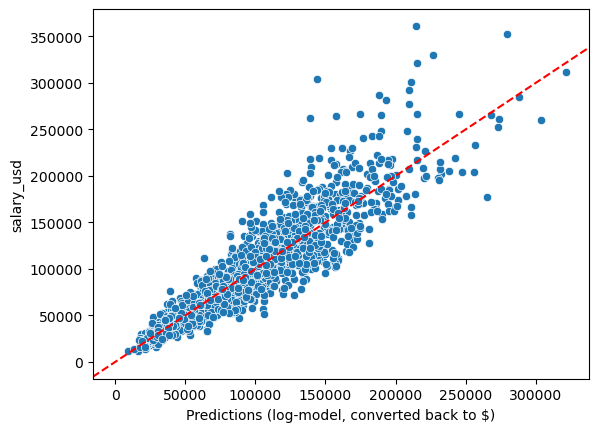

In [29]:
sns.scatterplot(x=predictions_actual_scale, y=y_test)
plt.xlabel("Predictions (log-model, converted back to $)")
plt.axline((0, 0), slope=1, color='red', linestyle='--')  

In [30]:
coefs = pd.DataFrame({  'feature': X.columns, 'coefficient': lm_log.coef_})

In [31]:
coefs['pct_change'] = (np.exp(coefs['coefficient']) - 1) * 100


In [32]:
coefs = coefs.sort_values('pct_change', key=abs, ascending=False)


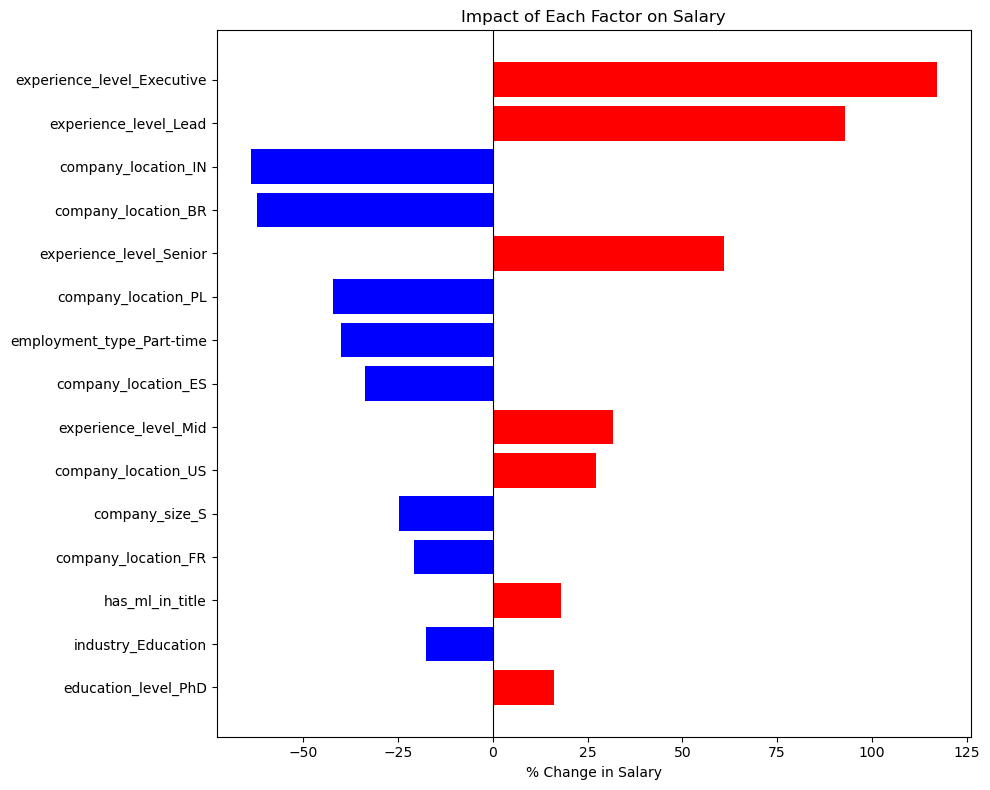

In [33]:
trim_ = coefs.head(15)
plt.figure(figsize=(10, 8))
colors = ['red' if x > 0 else 'blue' for x in trim_['pct_change']]
plt.barh(trim_['feature'], trim_['pct_change'], color=colors)
plt.xlabel('% Change in Salary')
plt.title('Impact of Each Factor on Salary')
plt.axvline(0, color='black', linewidth=0.8)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Interpreting Coefficients as Percent Change
Since the log-model coefficients represent changes in log salary rather than dollar amounts, they were converted using `(np.exp(coefs['coefficient']) - 1) * 100` to show their effects on salary as percentages. The chart displays the top 15 features based on the magnitude of their impact. Red indicates features associated with a salary increase, while blue indicates features associated with a salary decrease, all shown together in one graph.

## Conclusion
This project used linear regression to predict AI/data science salaries using a combination of numerical and categorical features. The baseline model reached an R² of 0.779, but residual analysis showed it struggled with high earners (heteroscedasticity). Log-transforming the target improved the model, and R² improved to 0.831; errors dropped by 15-20%, and negative predictions were removed.

Key findings: When it came to the biggest impacts on salary, seniority and company location were the main differences. Having "ML" in a job title and holding a PhD also came with real pay increases. Daily AI-tool use showed a small positive effect.

Limitations: the data is synthetic, so these findings reflect patterns in this dataset, not real-world salary guarantees. A linear model also can't capture non-linear effects (e.g., seniority interacting with industry) — a good next step for future work.